# 1. Data exploration

### GBIF

GBIF data is large (~20GB)  
Use DuckDB to explore and read in relevant chunks, then save a smaller, working dataframe for modelling.

This notebook reads in the raw data from gbif and outputs a reduced dataframe with only relevant columns and without NAs or duplicates, as a csv.

In [1]:
import duckdb
import numpy as np
import pandas as pd

In [2]:
gbif = '../data/raw/gbif_raw.csv'

df = duckdb.query(f"""
    SELECT *
    FROM '{gbif}'
    LIMIT 3
""").to_df()

df

,gbifID,datasetKey,occurrenceID,kingdom,phylum,class,order,family,genus,species,...,identifiedBy,dateIdentified,license,rightsHolder,recordedBy,typeStatus,establishmentMeans,lastInterpreted,mediaType,issue
0,1065276918,005eb8d8-ed94-41be-89cf-e3115a9058e4,0018f511-e551-461b-a90c-92a671bc7afe,Animalia,Mollusca,Gastropoda,Stylommatophora,Geomitridae,Xerolenta,Xerolenta obvia,...,J. Gerber : Field Museum of Natural History - ...,2013-01-01,CC0_1_0,The Field Museum of Natural History,J. Gerber,None,None,2026-03-19 18:02:13.916000+01:00,None,OCCURRENCE_STATUS_INFERRED_FROM_INDIVIDUAL_COU...
1,4170719314,005eb8d8-ed94-41be-89cf-e3115a9058e4,0c302b8a-7d4b-453d-86d9-5df306737116,Animalia,Mollusca,Gastropoda,Stylommatophora,Enidae,Zebrina,Zebrina detrita,...,J. Gerber : Field Museum of Natural History - ...,2009-01-01,CC0_1_0,The Field Museum of Natural History,J. Gerber,None,None,2026-03-19 18:02:14.166000+01:00,None,OCCURRENCE_STATUS_INFERRED_FROM_INDIVIDUAL_COU...
2,1065281200,005eb8d8-ed94-41be-89cf-e3115a9058e4,227d46bd-3785-498f-8a95-6062be2a4075,Animalia,Mollusca,Gastropoda,Stylommatophora,Pupillidae,Pupilla,Pupilla muscorum,...,J. Gerber : Field Museum of Natural History - ...,2013-01-01,CC0_1_0,The Field Museum of Natural History,"J. Gerber, T. C. Gerber, Z. Ren",None,None,2026-03-19 18:02:15.254000+01:00,None,OCCURRENCE_STATUS_INFERRED_FROM_INDIVIDUAL_COU...


In [3]:
df.columns

Index(['gbifID', 'datasetKey', 'occurrenceID', 'kingdom', 'phylum', 'class',
       'order', 'family', 'genus', 'species', 'infraspecificEpithet',
       'taxonRank', 'scientificName', 'verbatimScientificName',
       'verbatimScientificNameAuthorship', 'countryCode', 'locality',
       'stateProvince', 'occurrenceStatus', 'individualCount',
       'publishingOrgKey', 'decimalLatitude', 'decimalLongitude',
       'coordinateUncertaintyInMeters', 'coordinatePrecision', 'elevation',
       'elevationAccuracy', 'depth', 'depthAccuracy', 'eventDate', 'day',
       'month', 'year', 'taxonKey', 'speciesKey', 'basisOfRecord',
       'institutionCode', 'collectionCode', 'catalogNumber', 'recordNumber',
       'identifiedBy', 'dateIdentified', 'license', 'rightsHolder',
       'recordedBy', 'typeStatus', 'establishmentMeans', 'lastInterpreted',
       'mediaType', 'issue'],
      dtype='str')

In [4]:
# Disable strict quoting
# Sometimes GBIF-style data has messy quoting. Try:

duckdb.query(f"""
    SELECT DISTINCT taxonRank
    FROM read_csv('{gbif}', quote='', escape='')
""")

┌────────────┐
│ taxonRank  │
│  varchar   │
├────────────┤
│ ORDER      │
│ VARIETY    │
│ PHYLUM     │
│ FAMILY     │
│ SPECIES    │
│ GENUS      │
│ CLASS      │
│ SUBSPECIES │
│ FORM       │
│ UNRANKED   │
│ KINGDOM    │
└────────────┘
   11 rows  

In [5]:
# Can depth help filter out marine species?

duckdb.query(f"""
    SELECT DISTINCT phylum
    FROM read_csv('{gbif}', quote='', escape='')
    WHERE depth IS NOT NULL
""")

┌─────────────────┐
│     phylum      │
│     varchar     │
├─────────────────┤
│ Phoronida       │
│ Xenacoelomorpha │
│ Entoprocta      │
│ Gastrotricha    │
│ Nematoda        │
│ Hemichordata    │
│ Bryozoa         │
│ Priapulida      │
│ Arthropoda      │
│ Chordata        │
│ Rotifera        │
│ Tardigrada      │
│ Mollusca        │
│ Annelida        │
│ Nemertea        │
│ Porifera        │
│ Platyhelminthes │
│ Cnidaria        │
│ Ctenophora      │
│ Sipuncula       │
│ NULL            │
│ Echinodermata   │
│ Chaetognatha    │
└─────────────────┘
      23 rows    

In [6]:
duckdb.query(f"""
    SELECT genus, species, depth
    FROM read_csv('{gbif}', quote='', escape='')
    WHERE depth IS NOT NULL
    LIMIT 25
""")

┌────────────────┬────────────────────────┬────────┐
│     genus      │        species         │ depth  │
│    varchar     │        varchar         │ double │
├────────────────┼────────────────────────┼────────┤
│ NULL           │ NULL                   │    9.5 │
│ Lagis          │ Lagis koreni           │   19.0 │
│ Monopseudocuma │ Monopseudocuma gilsoni │   17.3 │
│ NULL           │ NULL                   │   22.0 │
│ Chaetozone     │ NULL                   │   14.3 │
│ Macomangulus   │ Macomangulus tenuis    │    9.2 │
│ Pariambus      │ NULL                   │    9.5 │
│ Gyas           │ Gyas titanus           │  720.0 │
│ Echinocardium  │ Echinocardium cordatum │   39.0 │
│ Pagurus        │ Pagurus bernhardus     │   39.0 │
│    ·           │  ·                     │     ·  │
│    ·           │  ·                     │     ·  │
│    ·           │  ·                     │     ·  │
│ Mytilus        │ NULL                   │    1.0 │
│ Mitostoma      │ Mitostoma chrysomelas  │ 21

Looks reasonable to exclude based on depth IS NOT NULL - how many rows do we lose?

In [7]:
duckdb.query(f"""
    SELECT COUNT(*) FILTER (WHERE depth IS NOT NULL) AS n_depth, 
           COUNT(*) FILTER (WHERE depth IS NOT NULL) * 1.0 / COUNT(*) AS depth_frac,
    FROM read_csv('{gbif}', quote='', escape='')
""")

┌─────────┬───────────────────────┐
│ n_depth │      depth_frac       │
│  int64  │        double         │
├─────────┼───────────────────────┤
│  221238 │ 0.0060290564779232995 │
└─────────┴───────────────────────┘

Only a tiny fraction of the dataset has depth - filter these out.

---
Investigate basisOfRecord

In [8]:
duckdb.query(f"""
    SELECT basisOfRecord, COUNT(*)
    FROM read_csv('{gbif}', quote='', escape='')
    GROUP BY basisOfRecord
""")

┌─────────────────────┬──────────────┐
│    basisOfRecord    │ count_star() │
│       varchar       │    int64     │
├─────────────────────┼──────────────┤
│ FOSSIL_SPECIMEN     │         4299 │
│ MACHINE_OBSERVATION │       145816 │
│ MATERIAL_SAMPLE     │       568031 │
│ OBSERVATION         │         4128 │
│ PRESERVED_SPECIMEN  │       315588 │
│ OCCURRENCE          │        78697 │
│ LIVING_SPECIMEN     │        36313 │
│ HUMAN_OBSERVATION   │     35541618 │
│ MATERIAL_CITATION   │          804 │
└─────────────────────┴──────────────┘

We don't need fossil specimens, preserved specimens - not useful for current biodiversity trends.  
Let's stick to human observations only for now - no need to worry about different collection methods and their own biases.

In [9]:
# How many are missing species names?
duckdb.query(f"""
    SELECT COUNT(*) AS missing_species
    FROM read_csv('{gbif}', quote='', escape='')
    WHERE species IS NULL
    GROUP BY species
""")

┌─────────────────┐
│ missing_species │
│      int64      │
├─────────────────┤
│         1155668 │
└─────────────────┘

--- 
Investigate missing values of species or genus

In [10]:
# proportion of dataset missing different taxonomic level info

duckdb.query(f"""SELECT 
    COUNT(*) AS total_rows,
    COUNT(*) FILTER (WHERE species IS NULL) AS species_missing,
    COUNT(*) FILTER (WHERE genus IS NULL) AS genus_missing,
    COUNT(*) FILTER (WHERE species IS NULL) * 1.0 / COUNT(*) AS species_missing_frac,
    COUNT(*) FILTER (WHERE genus IS NULL) * 1.0 / COUNT(*) AS genus_missing_frac,
FROM read_csv_auto(
    '{gbif}',           -- your CSV path
    delim='\t',         -- GBIF exports are usually tab-separated
    ignore_errors=true, -- skip malformed rows
    sample_size=-1      -- sample all rows for proper type inference
)
""")

┌────────────┬─────────────────┬───────────────┬──────────────────────┬─────────────────────┐
│ total_rows │ species_missing │ genus_missing │ species_missing_frac │ genus_missing_frac  │
│   int64    │      int64      │     int64     │        double        │       double        │
├────────────┼─────────────────┼───────────────┼──────────────────────┼─────────────────────┤
│   36695294 │         1155668 │        497084 │  0.03149362967360338 │ 0.01354626018257273 │
└────────────┴─────────────────┴───────────────┴──────────────────────┴─────────────────────┘

In [11]:
# Do all rows indicate a species is present? Or are some indicating absence?
duckdb.query(f"""
    SELECT COUNT(DISTINCT(occurrenceStatus))
    FROM read_csv('{gbif}', quote='', escape='')
""")

┌──────────────────────────────────┐
│ count(DISTINCT occurrenceStatus) │
│              int64               │
├──────────────────────────────────┤
│                                1 │
└──────────────────────────────────┘

Columns to keep:
- gbifID: Unique GBIF key for the occurrence.
- species: The species name (excluding authorship) for the species from the GBIF backbone matched to this occurrence.
    - note that species has missing values - must exclude these (or use genus instead? genus also has missing values though)
- ~~locality: The specific description of the place.~~
- ~~stateProvince: The name of the next-smaller administrative region than country (state, province, canton, department, region, etc.) in which the occurrence occurs.~~
- decimalLatitude: The geographic latitude (in decimal degrees, using the WGS84 datum) of the geographic centre of the location of the occurrence
- decimalLongitude: The geographic longitude (in decimal degrees, using the WGS84 datum) of the geographic centre of the location of the occurrence.
- ~~elevation: Elevation (altitude) in metres above sea level. This is not a current Darwin Core term.~~
- ~~eventDate: The date-time during which an Event occurred. For occurrences, this is the date-time when the event was recorded. Not suitable for a time in a geological context.~~
- month
- year
- basisOfRecord: The values of the Darwin Core term Basis of Record which can apply to occurrences. (for filtering out human observations if needed)
- depth: (for excluding rows with depth in final dataset)

In [12]:
cols_to_keep = ['gbifID', 'species', 'decimalLatitude', 'decimalLongitude', 'month', 'year', 'basisOfRecord', 'depth']

What about columns not kept?

- individualCount:
    - While GBIF provides the individualCount field, this project focuses on species presence rather than abundance due to heterogeneous reporting practices across datasets. Each occurrence is treated equally for computing species richness and stability.

Save only required columns to dataframe and remove duplicates and rows with missing values for species, latitude or longitude

In [13]:
cols_sql = ", ".join(cols_to_keep)

reduced_df = duckdb.query(f"""
    SELECT {cols_sql}
    FROM read_csv('{gbif}', quote='', escape='')
    WHERE species IS NOT NULL 
        AND decimalLatitude IS NOT NULL 
        AND decimalLongitude IS NOT NULL
        AND month IS NOT NULL
        AND year IS NOT NULL
        AND basisOfRecord == 'HUMAN_OBSERVATION'
        AND depth IS NULL
""").to_df()

reduced_df

,gbifID,species,decimalLatitude,decimalLongitude,month,year,basisOfRecord,depth
0,3909594797,Altica oleracea,49.849400,6.343970,7,2003,HUMAN_OBSERVATION,NaN
1,1950445705,Bembecia ichneumoniformis,49.811500,6.518220,7,1999,HUMAN_OBSERVATION,NaN
2,1950546223,Hydrometra stagnorum,49.888300,6.255200,6,2000,HUMAN_OBSERVATION,NaN
3,4508288286,Oxygastra curtisii,49.921300,6.226240,7,2013,HUMAN_OBSERVATION,NaN
4,1950532249,Pechipogo strigilata,49.444100,7.766500,7,2001,HUMAN_OBSERVATION,NaN
...,...,...,...,...,...,...,...,...
34432718,2838344161,Milvus milvus,50.018064,6.753600,5,2019,HUMAN_OBSERVATION,NaN
34432719,3905990498,Agapanthia villosoviridescens,51.145018,6.310765,6,2022,HUMAN_OBSERVATION,NaN
34432720,3723401870,Pseudochorthippus parallelus,50.572655,10.182574,8,2020,HUMAN_OBSERVATION,NaN
34432721,4880977379,Bombus lapidarius,52.153853,8.419725,5,2020,HUMAN_OBSERVATION,NaN


Remove duplicates


In [14]:
reduced_df = reduced_df.drop_duplicates().copy()
reduced_df

,gbifID,species,decimalLatitude,decimalLongitude,month,year,basisOfRecord,depth
0,3909594797,Altica oleracea,49.849400,6.343970,7,2003,HUMAN_OBSERVATION,NaN
1,1950445705,Bembecia ichneumoniformis,49.811500,6.518220,7,1999,HUMAN_OBSERVATION,NaN
2,1950546223,Hydrometra stagnorum,49.888300,6.255200,6,2000,HUMAN_OBSERVATION,NaN
3,4508288286,Oxygastra curtisii,49.921300,6.226240,7,2013,HUMAN_OBSERVATION,NaN
4,1950532249,Pechipogo strigilata,49.444100,7.766500,7,2001,HUMAN_OBSERVATION,NaN
...,...,...,...,...,...,...,...,...
34432718,2838344161,Milvus milvus,50.018064,6.753600,5,2019,HUMAN_OBSERVATION,NaN
34432719,3905990498,Agapanthia villosoviridescens,51.145018,6.310765,6,2022,HUMAN_OBSERVATION,NaN
34432720,3723401870,Pseudochorthippus parallelus,50.572655,10.182574,8,2020,HUMAN_OBSERVATION,NaN
34432721,4880977379,Bombus lapidarius,52.153853,8.419725,5,2020,HUMAN_OBSERVATION,NaN


Remove depth column (no longer needed)

In [15]:
reduced_df = reduced_df.drop(columns='depth')

Check for missing values

In [16]:
reduced_df.isnull().sum()

gbifID              0
species             0
decimalLatitude     0
decimalLongitude    0
month               0
year                0
basisOfRecord       0
dtype: int64

Make sure lats and longs make sense  
For Germany, lats should be in the range: 47-55  
and longs should be in the range: 5-16

In [17]:
print(f'min lat: {min(reduced_df['decimalLatitude'])}')
print(f'max lat: {max(reduced_df['decimalLatitude'])}')
print(f'min long: {min(reduced_df['decimalLongitude'])}')
print(f'max long: {max(reduced_df['decimalLongitude'])}')

min lat: 47.223657
max lat: 55.9082
min long: 3.37833
max long: 15.042463


In [18]:
#Investigate point at longitude 3.37
reduced_df.loc[reduced_df['decimalLongitude']<3.5]

,gbifID,species,decimalLatitude,decimalLongitude,month,year,basisOfRecord
1084615,4113128440,Rissa tridactyla,55.83200,3.45100,6,2015,HUMAN_OBSERVATION
1084625,4113128542,Rissa tridactyla,55.84370,3.45660,6,2016,HUMAN_OBSERVATION
1093096,4113108294,Fulmarus glacialis,55.80220,3.43370,9,2014,HUMAN_OBSERVATION
1094619,4114328507,Uria aalge,55.80160,3.43980,6,2016,HUMAN_OBSERVATION
1097104,4115371902,Morus bassanus,55.86470,3.41660,9,2008,HUMAN_OBSERVATION
...,...,...,...,...,...,...,...
6338426,4130696447,Phocoena phocoena,55.74000,3.44667,5,2007,HUMAN_OBSERVATION
6338432,4130696461,Balaenoptera acutorostrata,55.84350,3.42633,4,2007,HUMAN_OBSERVATION
6338433,4130696462,Lagenorhynchus acutus,55.84667,3.43500,4,2007,HUMAN_OBSERVATION
6338434,4130696463,Balaenoptera acutorostrata,55.85583,3.47233,4,2007,HUMAN_OBSERVATION


These points seem to be over the sea - the polygons from the shapefile in notebook #2 should filter these out

---
plot distribution of observations over time

<Axes: xlabel='year'>

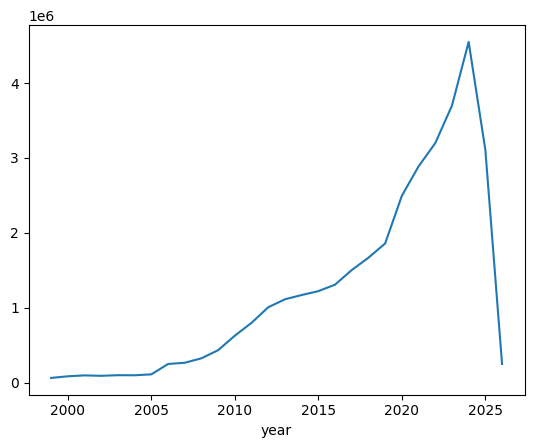

In [19]:
reduced_df['year'].value_counts().sort_index().plot()

Restrict data to 20 years - 2004-2024

In [20]:
year_mask = reduced_df['year'].between(2004, 2024)
reduced_df = reduced_df.loc[year_mask].copy()

reduced_df.describe()

,gbifID,decimalLatitude,decimalLongitude,month,year
count,3.062107e+07,3.062107e+07,3.062107e+07,3.062107e+07,3.062107e+07
mean,4.772018e+09,5.107937e+01,9.626106e+00,5.781548e+00,2.018758e+03
std,9.185423e+08,1.790496e+00,2.074171e+00,3.017684e+00,4.726032e+00
min,1.640919e+08,4.722366e+01,3.378330e+00,1.000000e+00,2.004000e+03
25%,4.534381e+09,4.977262e+01,8.100512e+00,4.000000e+00,2.016000e+03
50%,5.017306e+09,5.109123e+01,9.282532e+00,5.000000e+00,2.020000e+03
75%,5.028116e+09,5.240611e+01,1.093058e+01,8.000000e+00,2.023000e+03
max,6.181744e+09,5.590820e+01,1.504246e+01,1.200000e+01,2.024000e+03


<Axes: xlabel='month'>

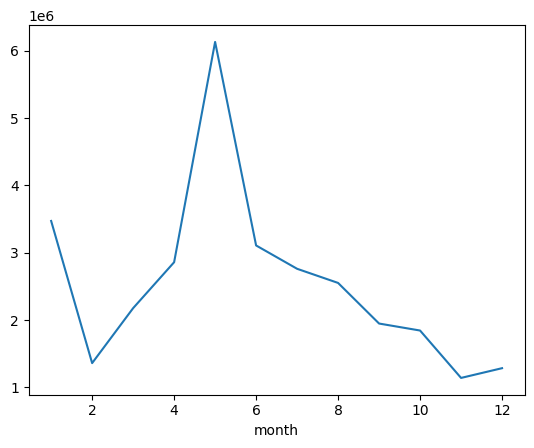

In [21]:
reduced_df['month'].value_counts().sort_index().plot()

---
Final sense check

In [22]:
reduced_df.describe()

,gbifID,decimalLatitude,decimalLongitude,month,year
count,3.062107e+07,3.062107e+07,3.062107e+07,3.062107e+07,3.062107e+07
mean,4.772018e+09,5.107937e+01,9.626106e+00,5.781548e+00,2.018758e+03
std,9.185423e+08,1.790496e+00,2.074171e+00,3.017684e+00,4.726032e+00
min,1.640919e+08,4.722366e+01,3.378330e+00,1.000000e+00,2.004000e+03
25%,4.534381e+09,4.977262e+01,8.100512e+00,4.000000e+00,2.016000e+03
50%,5.017306e+09,5.109123e+01,9.282532e+00,5.000000e+00,2.020000e+03
75%,5.028116e+09,5.240611e+01,1.093058e+01,8.000000e+00,2.023000e+03
max,6.181744e+09,5.590820e+01,1.504246e+01,1.200000e+01,2.024000e+03


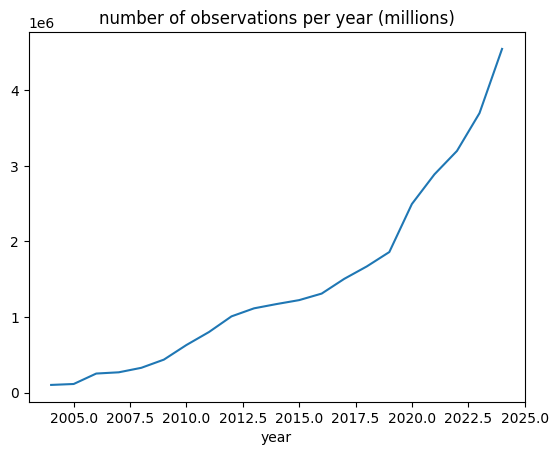

In [23]:
reduced_df['year'].value_counts().sort_index().plot(title='number of observations per year (millions)');

---
Check for potential typos in species names

In [7]:
reduced_df.value_counts('species').sort_values(ascending=True).head(50)

species
Rhagoletis batava             1
Gelis pilosulus               1
Karsholtia marianii           1
Asplanchna brightwellii       1
Dichrorampha velata           1
Testudo marginata             1
Strophosomus melanogrammus    1
Trichocera forcipula          1
Cheilosia lasiopa             1
Placusa depressa              1
Megachile erimae              1
Microplana scharffi           1
Trychosis legator             1
Philonthus rufipes            1
Euglesa subtruncata           1
Gareila nivata                1
Heliozela hammoniella         1
Bulweria bulwerii             1
Platycheirus nielseni         1
Mytilina trigona              1
Orthonevra tristis            1
Calosota aestivalis           1
Argyresthia thuiella          1
Chrysogaster aerosa           1
Stigmella paradoxa            1
Lathrobium rufipenne          1
Gelis forticornis             1
Acleris roscidana             1
Heliodines roesella           1
Charpentieria itala           1
Onychoprion anaethetus        1


There are a lot of single observation species - these could be typos or genuinely rare species.  

Danger in removing singletons:
- underestimate biodiversity
- bias toward common species
- lose ecological signal  
But keeping all of them:
- can inflate richness slightly
- introduces noise

Compromise on the trade-off and keep these species in. 
- noise from singletons is small relative to total data
- model + aggregation smooths it out

For presentation:
All species observations were retained to preserve rare species signals, while controlling for sampling effort to mitigate biases from uneven observation intensity.

---
Save dataframe to parquet (faster to read/write and supports compression - important for large files like this)

In [24]:
reduced_df.info()

<class 'pandas.DataFrame'>
Index: 30621074 entries, 3 to 34432722
Data columns (total 7 columns):
 #   Column            Dtype  
---  ------            -----  
 0   gbifID            int64  
 1   species           str    
 2   decimalLatitude   float64
 3   decimalLongitude  float64
 4   month             int64  
 5   year              int64  
 6   basisOfRecord     str    
dtypes: float64(2), int64(3), str(2)
memory usage: 2.8 GB


In [ ]:
# reduced_df.to_csv('../Data/Processed/gbif_processed.csv')

In [25]:
import pyarrow

reduced_df.to_parquet('../Data/Processed/gbif_processed.parquet', index=False)

In [31]:
reduced_df.shape

(30621074, 7)